<a href="https://colab.research.google.com/github/wongihun/natural-language/blob/main/%EB%8C%80%EC%8B%A0%EA%B3%A0_LLM_%EA%B3%BC%EC%A0%95_%EC%A0%84%EC%B2%98%EB%A6%AC%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 전처리
- 특수 기호 제거
- 불용어 제거

In [ ]:
test_text = """
안녕하세요. 저는 대신고등학교 1학년 홍길동입니다!
오늘은 컴퓨터 동아리에서 LLM 개발을 위한 자연어 전처리 방법을 배워볼까 합니다.
요즘 유튜브에는 브레인롯 쇼츠가 범람하고 있습니다.
"""

In [ ]:
# 전처리-1
# 특수 기호 제거
# \n : 줄넘김 문자
test_text = test_text.replace('\n',' ')
test_text = test_text.replace('.','')
test_text = test_text.replace('!','')

print(test_text)

 안녕하세요 저는 대신고등학교 1학년 홍길동입니다 오늘은 컴퓨터 동아리에서 LLM 개발을 위한 자연어 전처리 방법을 배워볼까 합니다 요즘 유튜브에는 브레인롯 쇼츠가 범람하고 있습니다 


In [ ]:
# 전처리-2(옵션)
# 불용어 제거
# 은, 는 과 같은 자체적인 의미가 없는 문자의 제거
remove_list = ['을','를','이','은','는','에','가','서','하고','입니다','습니다','하세요','까','니다']
refine_text = test_text
for r in remove_list :
  refine_text = refine_text.replace(r,'')
print(refine_text)

 안녕 저 대신고등학교 1학년 홍길동 오늘 컴퓨터 동아리 LLM 개발 위한 자연어 전처리 방법 배워볼 합 요즘 유튜브 브레인롯 쇼츠 범람 있 


2. 토큰화
- 띄어쓰기 기반 토큰화
- 형태소 기반 토큰화
- subword 토큰화

### 띄어쓰기 기반 토큰화
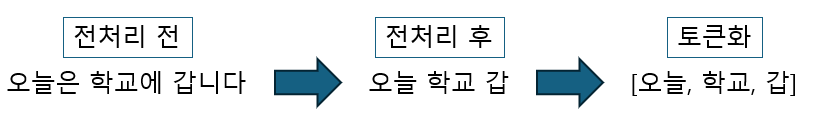

In [ ]:
sampletext = "오늘은 학교에 갑니다"

#불용어 제거
deletelist = ['은','에','니다']
for r in deletelist :
  sampletext = sampletext.replace(r,'')

# 띄어쓰기 기반 토큰화
space_token = sampletext.split()

#아래의 주석 코드는 위에서 진행한 장문 데이터입니다.
#space_token = refine_text.split()
print(space_token)

['오늘', '학교', '갑']


In [ ]:
#토그나이저 라이브러리
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 19.4 MB/s eta 0:00:00


## 형태소 기반 토큰화


In [ ]:
# 형태소 기반 토큰화 : Okt
from konlpy.tag import Okt
okt = Okt()

test_text = "안녕하세요. 저는 대신고등학교 1학년 홍길동입니다!"

tokens = okt.morphs(test_text)

print(tokens)

['안녕하세요', '.', '저', '는', '대신', '고등학교', '1', '학년', '홍길동', '입니다', '!']




---
##Okt의 표기 품사

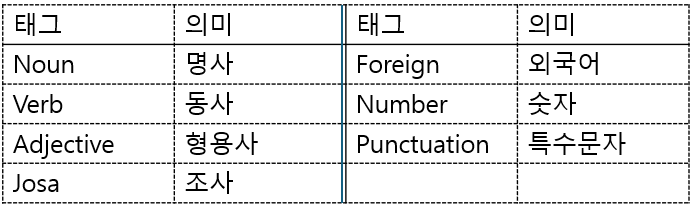

In [ ]:
# 필요에 따라 이후의 값들 중 불용어, 특수 기호 제거
tokens = okt.pos(test_text)
print(tokens)

[('안녕하세요', 'Adjective'), ('.', 'Punctuation'), ('저', 'Noun'), ('는', 'Josa'), ('대신', 'Noun'), ('고등학교', 'Noun'), ('1', 'Number'), ('학년', 'Noun'), ('홍길동', 'Noun'), ('입니다', 'Adjective'), ('!', 'Punctuation')]


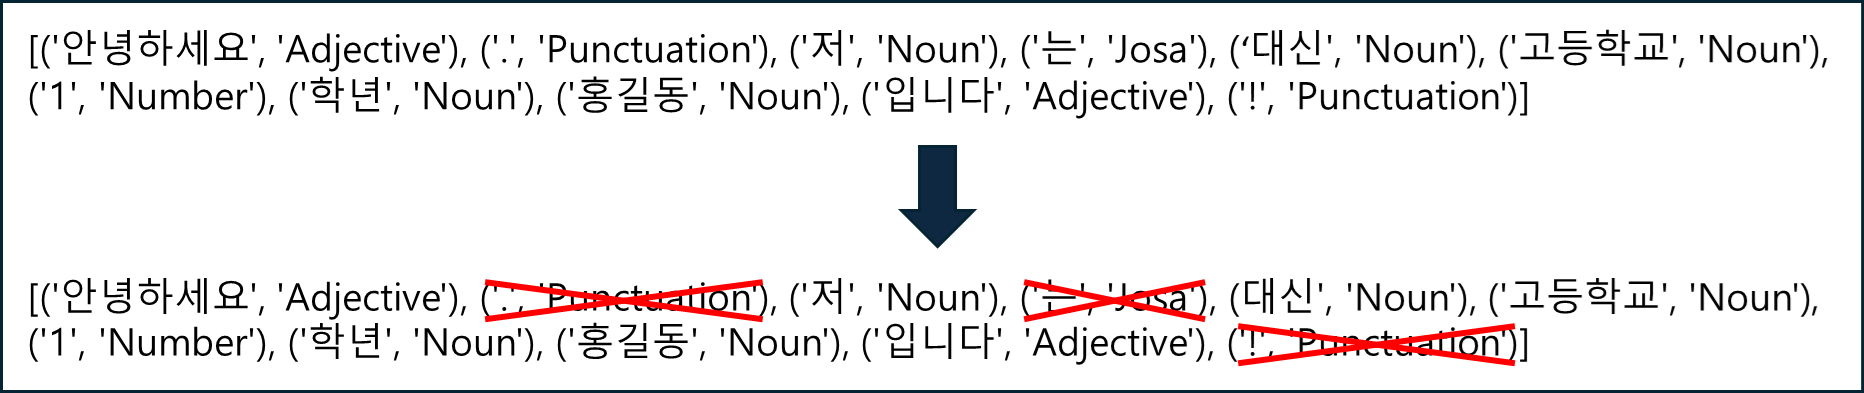

In [ ]:
okt_tokens = []

for i in range(len(tokens)) :
  if tokens[i][1] not in ['Punctuation','Josa'] :
    okt_tokens.append(tokens[i][0])

print(okt_tokens)

['안녕하세요', '저', '대신', '고등학교', '1', '학년', '홍길동', '입니다']


##subword 기반 토그나이징
- 문자열을 분해, 통계적으로 가장 많이 등장하는 조합을 활용한다.

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# 학습 데이터
# 5개의 문장 중, "사과"라는 단어가 들어간 문장이 4개
# 통계적 빈도수가 높은 편
texts = [
    "사과를 좋아합니다.",
    "사과 주스를 마십니다.",
    "사과 파이를 먹습니다.",
    "사과를 정말 좋아합니다.",
    "딸기는 싱싱합니다."
]

# tokenizer 객체 생성
tokenizer = Tokenizer(BPE())

# 공백 기준 분리 포함
tokenizer.pre_tokenizer = Whitespace()

# 학습 설정
trainer = BpeTrainer(
    vocab_size=50,
    min_frequency=2
)

# 직접 학습
tokenizer.train_from_iterator(
    texts,
    trainer=trainer
)

In [ ]:
test_text = """
사과를 참 좋아하는 저는 사과 파이를 만들어볼까 합니다.
사과를 적당한 크기로 자르고, 갈아서 준비를 하고, 준비한 시트에 설탕과 재료를 넣습니다.
마침 냉장고에 사과 주스가 있으니 함께 먹고 쉬려고 해요.
딸기 주스도 있답니다.
"""

output = tokenizer.encode(
   test_text
)

print(output.tokens)

['사과를', '좋', '아', '는', '는', '사과', '파', '이', '를', '합니다', '.', '사과를', '기', '아', '를', '과', '를', '습', '니다', '.', '마', '사과', '주', '스', '니', '먹', '.', '딸', '기', '주', '스', '니다', '.']


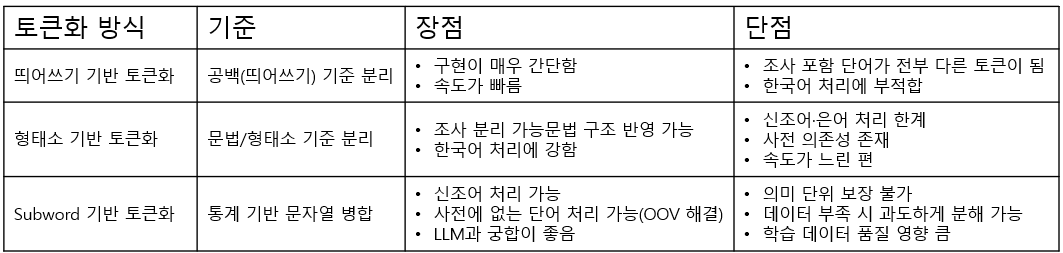



---


## 벡터화
- 인공지능(모델)이 이해할 수 있도록 텍스트의 정수화



---


##원-핫 인코딩(One-hot encoding)
- 토큰화한 단어들에 대해 각각 위치 값을 부여
- 리스트에서 부여된 위치에 해당되는 위치의 값을 1로, 해당되지 않는 위치의 값은 0으로 지정
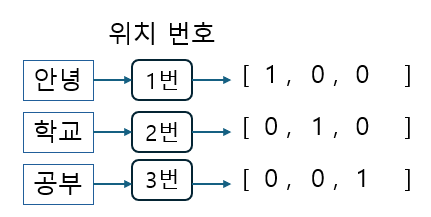

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

#안녕! 학교에서 공부했어!
#전처리 → 안녕, 학교, 공부
words = np.array([
    ['안녕'],
    ['학교'],
    ['공부']
])

#one-hot encoding
#단어의 고유한 위치를 0, 1로만 표기
encoder = OneHotEncoder()

result = encoder.fit_transform(words)

print(result.toarray())

[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]




---

##TF-IDF
- TF(Term Frequency) : 문장에서의 단어 빈도
- IDF(Inverse Document Frequency) : 단어의 희귀도

### TF 계산법
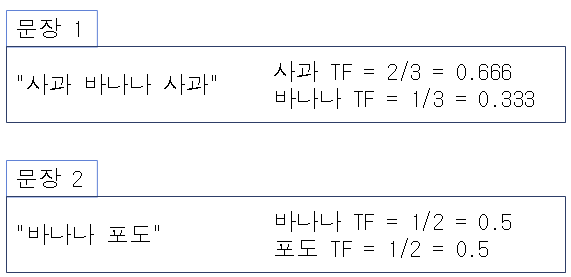

###IDF 계산법
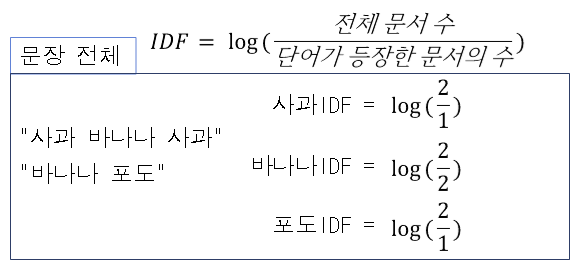

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "사과 바나나 사과",
    "바나나 포도"
]

#TF-IDF : TF X IDF(두 요소의 곱)
#문장에서 단어의 빈도, 중요도를 기반으로 계산
vectorizer = TfidfVectorizer()

result = vectorizer.fit_transform(texts)

print(result.toarray())

[[0.33517574 0.94215562 0.        ]
 [0.57973867 0.         0.81480247]]


In [ ]:
columns=vectorizer.get_feature_names_out()
print(columns)

['바나나' '사과' '포도']




---

##Word2Vec
- 비슷한 의미의 단어는 벡터 공간에서도 가까운 곳에 위치함
- 앞 뒤의 문장 패턴에 따라 최적 단어를 예측

- 학습된 토큰들은 좌표와 같은 값을 가지며, 유사한 의미를 가지는 토큰인 경우 거리상 가까움

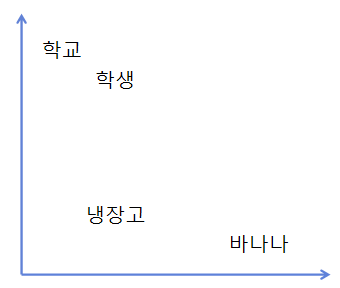

- 예측이 필요한 부분을 기준으로 앞 뒤의 단어를 확인하여 단어를 예측
- 이때, 예시의 경우 해당 위치에는 학습된 단어 중 앞 뒤와 연관된 단어 배치가 가능하다.

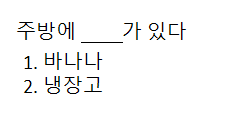

In [ ]:
# 라이브러리 설치
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.2 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
import numpy as np

sentences = [
    ['나는', '학교에', '간다'],
    ['학생이', '공부를', '한다'],
    ['냉장고에','바나나가','있다']
]

# Word2Vec
model = Word2Vec(
    sentences,
    vector_size=3,
    window=5,
    min_count=1
)

print(model.wv['학교에'])
print(model.wv['학생이'])
print(model.wv['바나나가'])

[0.16900873 0.22525644 0.02542885]
[-0.06053392  0.09588599  0.03306246]
[ 0.3003091  -0.31009832 -0.23722696]


In [ ]:
# 거리 측정 함수
def euclidean_distance(v1, v2):
    return np.sqrt(np.sum((v1 - v2) ** 2))

In [ ]:
# 거리 계산
dist_student_school = euclidean_distance(model.wv['학생이'], model.wv['학교에'])
dist_student_banana = euclidean_distance(model.wv['학생이'], model.wv['바나나가'])

# 출력
print("학생 ↔ 학교 거리 :", dist_student_school)
print("학생 ↔ 바나나 거리 :", dist_student_banana)

학생 ↔ 학교 거리 : 0.26359972
학생 ↔ 바나나 거리 : 0.606702




---

##bert
- 문장 전체를 확인하여 체크(Encoder 응용)
- 문장을 "이해"하는데에 특화

In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-multilingual-cased"
)

model = AutoModel.from_pretrained(
    "bert-base-multilingual-cased"
)

text = "은행에 갔다"

#bert embedding
#문맥을 동시에 참고하여 단어를 예측하는 방식
inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)

print(outputs.last_hidden_state)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[[ 0.0935, -0.3787,  0.2147,  ...,  0.3784,  0.1047,  0.2732],
         [ 0.1701, -0.7368,  0.2040,  ...,  0.6863,  0.3003,  0.3174],
         [-0.0980, -0.5490,  0.5995,  ...,  0.6336,  0.3119,  0.4292],
         ...,
         [ 0.0994, -0.7897,  0.7528,  ..., -0.4292, -0.0566,  0.5268],
         [ 0.3565, -0.8834,  0.6611,  ...,  0.3775,  0.3314,  0.5165],
         [ 0.0791, -0.8559,  0.6399,  ...,  0.6501,  0.0266,  0.6156]]],
       grad_fn=<NativeLayerNormBackward0>)




---
## 벡터화 비교


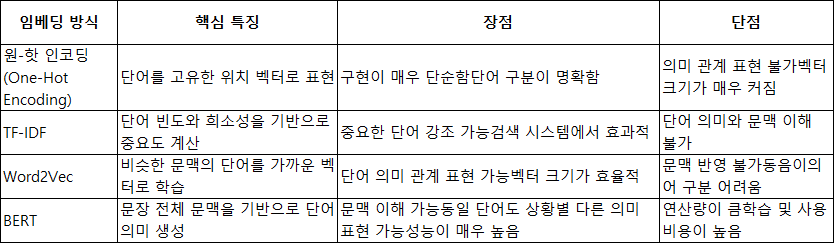